In [2]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.stats.multitest
import networkx as nx
from tqdm import tqdm

import concurrent.futures
from functools import partial
from itertools import product
from functools import partial

import pyBigWig
import pyranges1 as pr
import datasources
from knots_tools import *

In [3]:
ccds_pr_all, _ = load_cknots_base_data()

# RNA-seq

In [4]:
gr = pr.read_gtf("./data/rnaseq/gencode.v29.annotation.gtf")

In [5]:
genes = gr.copy()
genes = genes[(genes.Feature == "gene") & (genes.gene_type == 'protein_coding')].copy()

genes["gene_id"] = genes.gene_id.str.replace(r"\.\d+$", "", regex=True)

genes["TSS"] = genes.Start
genes.loc[genes.Strand == "-", "TSS"] = genes.loc[genes.Strand == "-", "End"] - 1
genes

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,havana_transcript,exon_number,exon_id,ont,protein_id,ccdsid,gene_na-e,havana_'ene,tAg,TSS
57,chr1,HAVANA,gene,65418,71585,.,+,.,ENSG00000186092,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65418
315,chr1,HAVANA,gene,450702,451697,.,-,.,ENSG00000284733,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,451696
443,chr1,HAVANA,gene,685678,686673,.,-,.,ENSG00000284662,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,686672
714,chr1,HAVANA,gene,923927,944581,.,+,.,ENSG00000187634,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,923927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741978,chrM,ENSEMBL,gene,10759,12137,.,+,.,ENSG00000198886,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10759
2741992,chrM,ENSEMBL,gene,12336,14148,.,+,.,ENSG00000198786,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12336
2741998,chrM,ENSEMBL,gene,14148,14673,.,-,.,ENSG00000198695,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14672
2742006,chrM,ENSEMBL,gene,14746,15887,.,+,.,ENSG00000198727,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14746


In [6]:
rnaseq_files = {
    ('GM12878', 1): './data/rnaseq/GM12878_R1_ENCFF866QJL.tsv',
    ('GM12878', 2): './data/rnaseq/GM12878_R2_ENCFF431UBR.tsv'
}

rnaseq_data = { idx: pd.read_csv(fn, sep='\t') for idx, fn in rnaseq_files.items() }

In [7]:
ccds_pr = ccds_pr_all.query('dataset == "GM12878"')\
    .reset_index()\
    .assign(is_nontrivial=lambda x: x['n_nodes'] >= 6)\
    .query('is_nontrivial')
ccds_pr

,index,dataset,Chromosome,ccd_id,Start,End,n_nodes,degree_min,degree_max,degree_mean,...,edge_betweenness_min,edge_betweenness_max,edge_betweenness_mean,n_edges_in_minors,edges_in_minors_ratio,n_minors,has_minors,density,length,is_nontrivial
0,0,GM12878,chr1,1,979903,1292598,144,1,31,3.833333,...,1.109141e-03,0.052735,0.012451,30,0.108696,3,True,0.026807,312695,True
1,1,GM12878,chr1,2,1396161,1444274,22,1,8,3.545455,...,2.319625e-02,0.131025,0.060384,0,0.000000,0,False,0.168831,48113,True
2,2,GM12878,chr1,3,2194421,2382994,70,1,15,3.285714,...,4.061915e-03,0.132888,0.028906,0,0.000000,0,False,0.047619,188573,True
3,3,GM12878,chr1,4,2414292,2550490,42,1,14,3.333333,...,9.291521e-03,0.107364,0.040883,0,0.000000,0,False,0.081301,136198,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2462,2462,GM12878,chrX,48,153548532,153671621,46,1,17,3.434783,...,9.710145e-03,0.121739,0.036886,0,0.000000,0,False,0.076329,123089,True
2463,2463,GM12878,chrX,49,153921716,153954431,6,1,4,2.666667,...,1.000000e-01,0.333333,0.191667,0,0.000000,0,False,0.533333,32715,True
2464,2464,GM12878,chrX,50,154396167,154528521,56,1,18,3.142857,...,1.948052e-03,0.126685,0.036843,0,0.000000,0,False,0.057143,132354,True
2465,2465,GM12878,chrX,51,2781305,155696236,52534,1,75,3.036205,...,1.449397e-09,0.021369,0.000138,0,0.000000,0,False,0.000058,152914931,True


In [8]:
cell_line = 'GM12878'
for irep in [1, 2]:
    rnaseq_df = rnaseq_data[cell_line, irep].copy()
    rnaseq_df = rnaseq_df[rnaseq_df.gene_id.str.match(r'^ENSG.*$')]
    rnaseq_df['gene_id'] = rnaseq_df.gene_id.str.extract(r'^(ENSG\d+)\..*')
    rnaseq_df = rnaseq_df.sort_values('gene_id')    
    rnaseq_df = pd.merge(rnaseq_df, genes, on='gene_id', how='inner')

    tss = rnaseq_df[['Chromosome', 'TSS', 'gene_id', 'TPM']]
    tss['L2TPM'] = np.log2(tss.TPM + 1)
    tss['Start'] = tss['TSS']
    tss['End'] = tss['TSS'] + 1
    tss_pr = pr.PyRanges(tss)

    jpr = ccds_pr.join_overlaps(tss_pr, join_type='left')

    aggpr = jpr.groupby(['Chromosome', 'ccd_id']).agg(
        has_minors = pd.NamedAgg('has_minors', 'first'),
        length_bp = pd.NamedAgg('length', 'first'),
        n_genes = pd.NamedAgg('gene_id', 'nunique'),
        n_genes_TPMgt1 = pd.NamedAgg('TPM', lambda x: (x > 1).sum()),
        L2TMP_med = pd.NamedAgg('L2TPM', 'median'),
        L2TMP_avg = pd.NamedAgg('L2TPM', 'mean'),
        TPM_max = pd.NamedAgg('TPM', 'max')        
    ).fillna(0).reset_index()
    aggpr['prop_genes_TPMgt1'] = (aggpr.n_genes_TPMgt1 / aggpr.n_genes)    
    print(aggpr)
    break

     Chromosome  ccd_id  has_minors  length_bp  n_genes  n_genes_TPMgt1  \
0          chr1       1        True     312695       14               4   
1          chr1       2       False      48113        5               2   
2          chr1       3       False     188573        2               1   
3          chr1       4       False     136198        3               1   
4          chr1       5       False      33954        2               1   
...         ...     ...         ...        ...      ...             ...   
2443       chrX      47       False      39095        3               1   
2444       chrX      48       False     123089        2               1   
2445       chrX      49       False      32715        3               2   
2446       chrX      50       False     132354       10               8   
2447       chrX      51       False  152914931      826             341   

      L2TMP_med  L2TMP_avg   TPM_max  prop_genes_TPMgt1  
0      0.000000   0.891498     24.15     

/home/michade/proj/knots/intrinsic_linking/knots_tools.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])


Mann-Whitney U test: statistic=305296.5000, p-value=0.010954 (data: n_genes). Median: non-linked=2.0000, linked=2.0000
Mann-Whitney U test: statistic=292740.0000, p-value=0.177933 (data: L2TMP_med). Median: non-linked=1.5052, linked=0.9635


/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])


Mann-Whitney U test: statistic=298378.0000, p-value=0.060875 (data: L2TMP_avg). Median: non-linked=1.9641, linked=1.5570
Mann-Whitney U test: statistic=305676.5000, p-value=0.010297 (data: TPM_max). Median: non-linked=16.3800, linked=11.3300


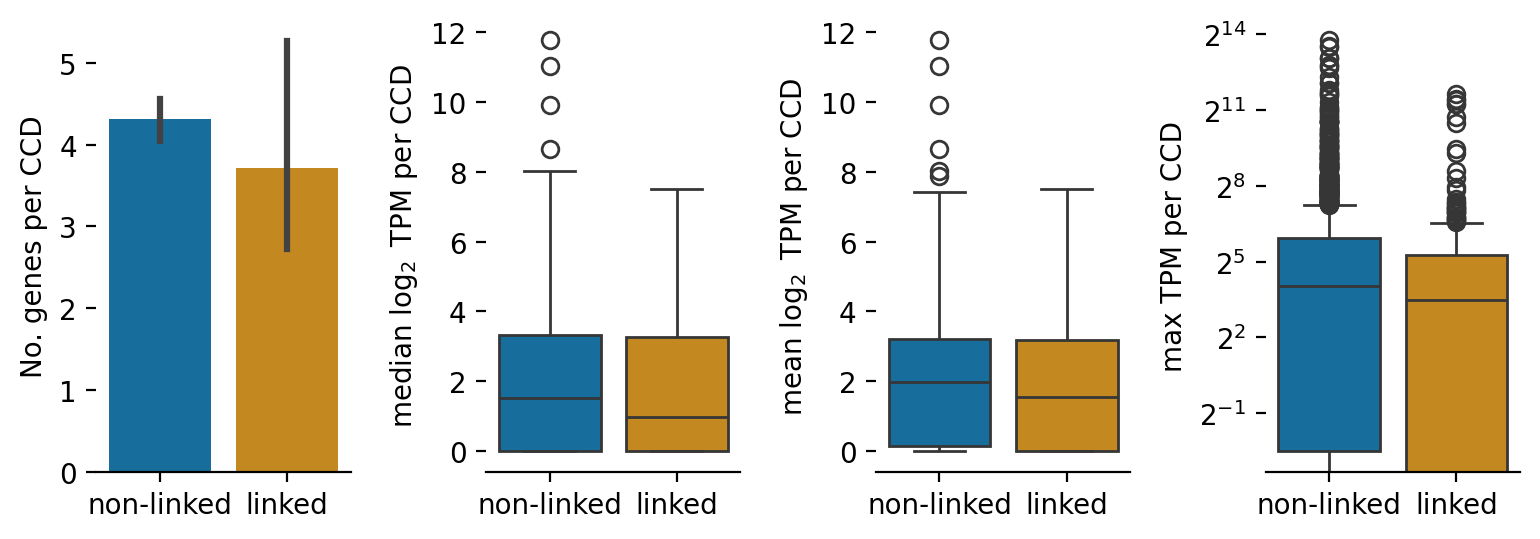

In [13]:
aggpr_clip = aggpr[aggpr.length_bp < 2e7]
_, axs = plt.subplots(1, 4, figsize=(7.8, 2.8), dpi=200)
compare_barplot(aggpr_clip, axs[0], 'n_genes', 'No. genes per CCD')
compare_boxplot(aggpr_clip, axs[1], 'L2TMP_med', 'median $\\log_2$ TPM per CCD')
compare_boxplot(aggpr_clip, axs[2], 'L2TMP_avg', 'mean $\\log_2$ TPM per CCD')
compare_boxplot(aggpr_clip, axs[3], 'TPM_max', 'max TPM per CCD')
axs[3].set_yscale('log', base=2)
plt.tight_layout()
# plt.savefig('./results/svg/expression.svg')